# Predicting defective parts from process sensor data (SECOM)

**Goal:** predict whether a manufactured part will fail final quality testing, using measurements from ~590 process sensors, and find which sensors are most related to failures.

**Dataset:** [SECOM](https://archive.ics.uci.edu/dataset/179/secom) from the UCI Machine Learning Repository. Real data from a semiconductor manufacturing line: 1567 parts, 590 anonymised sensor signals, a pass/fail label and a timestamp for each part.

**Why this dataset:** it has the typical problems of shop floor data: a lot of missing values, many useless (constant) signals, strongly imbalanced classes (few defects) and a process that changes over time.

**What this notebook covers:**
1. Exploratory analysis: missing data, class imbalance, defect rate over time
2. A leakage-safe preprocessing `Pipeline`
3. Comparing models with stratified cross-validation and the right metrics
4. Hyperparameter tuning with `GridSearchCV`
5. Choosing a decision threshold instead of using the default 0.5
6. Time-based validation (train on the past, test on the future)
7. Unsupervised anomaly detection with `IsolationForest`
8. Which sensors matter: permutation importance

In [19]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (train_test_split, StratifiedKFold, cross_validate,
                                     cross_val_predict, GridSearchCV)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, IsolationForest
from sklearn.inspection import permutation_importance
from sklearn.metrics import (roc_auc_score, average_precision_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve)

RANDOM_STATE = 42
plt.rcParams["figure.figsize"] = (8, 4)

## 1. Load the data

In [20]:
X = pd.read_csv("../data/secom.data", sep=" ", header=None)
X.columns = [f"sensor_{i:03d}" for i in range(X.shape[1])]

labels = pd.read_csv("../data/secom_labels.data", sep=" ", header=None, names=["label", "timestamp"])
labels["timestamp"] = pd.to_datetime(labels["timestamp"], format="%d/%m/%Y %H:%M:%S")

# In the original file -1 = pass, 1 = fail. I use 1 = defect, 0 = OK.
y = (labels["label"] == 1).astype(int)

print("Features:", X.shape)
print("Data sorted by time:", labels["timestamp"].is_monotonic_increasing)
X.iloc[:5, :8]

Features: (1567, 590)
Data sorted by time: True


,sensor_000,sensor_001,sensor_002,sensor_003,sensor_004,sensor_005,sensor_006,sensor_007
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235


## 2. Exploratory analysis

### Class imbalance

In [21]:
counts = y.value_counts().rename({0: "pass", 1: "fail"})
print(counts)
print(f"Defect rate: {y.mean():.1%}")

label
pass    1463
fail     104
Name: count, dtype: int64
Defect rate: 6.6%


Only about 6.6% of parts are defective. This means **accuracy is a useless metric here**: a model that always says "pass" gets ~93% accuracy and catches zero defects. I use these metrics instead:

- **Recall (fail class):** what share of real defects the model catches
- **Precision (fail class):** when the model raises an alarm, how often it is right
- **ROC AUC:** how well the model ranks defective parts above good ones (0.5 = random)
- **Average precision (PR AUC):** like ROC AUC but focused on the rare class, more honest for imbalanced data. The random baseline equals the defect rate (~0.066)

### Missing values and useless signals

Overall missing values: 4.5%
Sensors with any missing values: 538 of 590
Sensors with more than 50% missing: 28
Constant sensors (only one value): 116


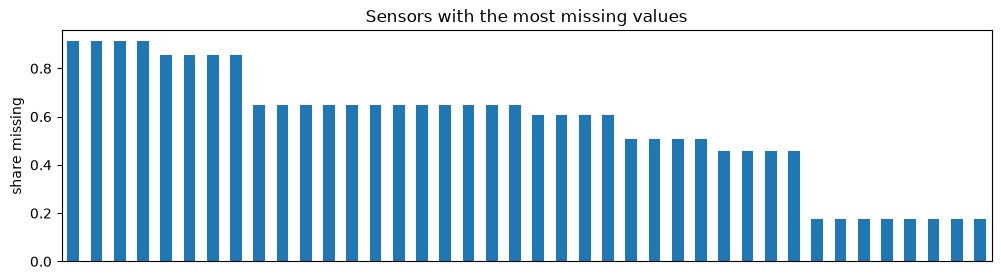

In [22]:
missing_share = X.isna().mean()
n_unique = X.nunique(dropna=True)

print(f"Overall missing values: {X.isna().mean().mean():.1%}")
print(f"Sensors with any missing values: {(missing_share > 0).sum()} of {X.shape[1]}")
print(f"Sensors with more than 50% missing: {(missing_share > 0.5).sum()}")
print(f"Constant sensors (only one value): {(n_unique <= 1).sum()}")

missing_share.sort_values(ascending=False).head(40).plot.bar(figsize=(12, 3), title="Sensors with the most missing values")
plt.ylabel("share missing"); plt.xticks([]); plt.show()

About 20% of the sensors are constant, so they carry no information. Some sensors are missing in most rows, probably because they were not installed or not logged for the whole period. Both have to be handled before modelling.

### Defect rate over time

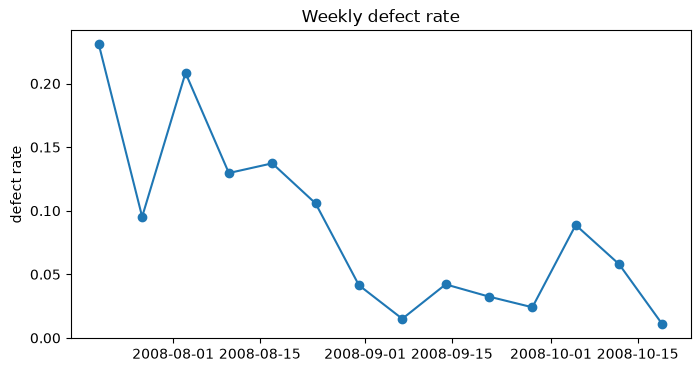

            mean  count
timestamp              
2008-07    0.222     63
2008-08    0.092    555
2008-09    0.029    590
2008-10    0.061    359


In [23]:
monthly = (pd.DataFrame({"ts": labels["timestamp"], "defect": y})
           .set_index("ts").resample("W")["defect"].agg(["mean", "count"]))
monthly = monthly[monthly["count"] > 0]

fig, ax = plt.subplots()
ax.plot(monthly.index, monthly["mean"], marker="o")
ax.set_title("Weekly defect rate"); ax.set_ylabel("defect rate")
plt.show()

print(labels.assign(defect=y).groupby(labels["timestamp"].dt.to_period("M"))["defect"].agg(["mean", "count"]).round(3))

**This is important.** The defect rate is not stable: around 22% in July, then it falls to about 3% in September. The process (or the way it was measured) changed over time. This has two consequences:
- a random train/test split may give an over-optimistic picture, because the model sees "the future" during training
- in production, a model trained once would probably degrade, so it needs monitoring and retraining

I come back to this in section 7.

## 3. Preprocessing pipeline

Steps:
1. Drop sensors with more than 50% missing values
2. Fill remaining gaps with the median of each sensor (`SimpleImputer`)
3. Drop constant sensors (`VarianceThreshold`)
4. Standardise (`StandardScaler`), needed for logistic regression, harmless for trees

**Everything is inside a `Pipeline` on purpose.** Each step learns something from data (which columns to drop, medians, means and standard deviations). If I fitted them on the full dataset before splitting, information from the test set would leak into training (data leakage) and the results would look better than they really are. With a `Pipeline`, during cross-validation every step is fitted only on the training folds.

Step 1 has no ready-made scikit-learn class, so I wrote a small custom transformer.

In [24]:
class DropMostlyMissing(BaseEstimator, TransformerMixin):
    """Drops columns whose share of missing values in the TRAINING data exceeds max_missing."""
    def __init__(self, max_missing=0.5):
        self.max_missing = max_missing

    def fit(self, X, y=None):
        self.keep_ = X.columns[X.isna().mean() <= self.max_missing]
        return self

    def transform(self, X):
        return X[self.keep_]


def make_pipeline(model):
    return Pipeline([
        ("drop_missing", DropMostlyMissing(max_missing=0.5)),
        ("impute", SimpleImputer(strategy="median")),
        ("drop_constant", VarianceThreshold(threshold=0.0)),
        ("scale", StandardScaler()),
        ("model", model),
    ])

## 4. Train/test split and model comparison

I hold out 25% of the data as a final test set (stratified, so both sets keep the ~6.6% defect rate) and compare models with 5-fold stratified cross-validation on the training part only.

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)
print(f"Train: {len(X_train)} parts, {y_train.sum()} defects")
print(f"Test:  {len(X_test)} parts, {y_test.sum()} defects")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    "Baseline (always predicts the prior)": DummyClassifier(strategy="prior"),
    "Logistic regression": LogisticRegression(C=0.01, class_weight="balanced", max_iter=5000),
    "Random forest": RandomForestClassifier(n_estimators=300, min_samples_leaf=3,
                                            class_weight="balanced_subsample",
                                            n_jobs=-1, random_state=RANDOM_STATE),
    "Gradient boosting": HistGradientBoostingClassifier(learning_rate=0.05, max_depth=3,
                                                        class_weight="balanced",
                                                        random_state=RANDOM_STATE),
}

rows = []
for name, model in models.items():
    scores = cross_validate(make_pipeline(model), X_train, y_train, cv=cv,
                            scoring=["roc_auc", "average_precision", "recall", "precision"])
    rows.append({"model": name,
                 "ROC AUC": scores["test_roc_auc"].mean(),
                 "Avg precision": scores["test_average_precision"].mean(),
                 "Recall @0.5": scores["test_recall"].mean(),
                 "Precision @0.5": scores["test_precision"].mean()})

results = pd.DataFrame(rows).set_index("model").round(3)
results

Train: 1175 parts, 78 defects
Test:  392 parts, 26 defects


,ROC AUC,Avg precision,Recall @0.5,Precision @0.5
model,,,,
Baseline (always predicts the prior),0.500,0.066,0.000,0.000
Logistic regression,0.665,0.184,0.348,0.142
Random forest,0.727,0.215,0.000,0.000
Gradient boosting,0.661,0.147,0.105,0.122


Observations:
- All real models beat the baseline, but the signal is weak. That is normal for SECOM: published results on this dataset are usually in a similar range.
- `class_weight="balanced"` tells the model that a missed defect costs more than a false alarm. Without it most models would just predict "pass".
- **Random forest has the best ranking (ROC AUC, average precision) but recall 0 at threshold 0.5.** It does order parts well, but its predicted probabilities for defects rarely go above 0.5. So the default threshold is the problem, not the model. Section 6 fixes this.

## 5. Tuning the random forest with GridSearchCV

I optimise average precision, because it focuses on the rare defect class.

In [26]:
param_grid = {
    "model__max_features": ["sqrt", 0.1],
    "model__min_samples_leaf": [1, 3, 10],
}
search = GridSearchCV(make_pipeline(RandomForestClassifier(n_estimators=300, class_weight="balanced_subsample",
                                                           n_jobs=-1, random_state=RANDOM_STATE)),
                      param_grid, scoring="average_precision", cv=cv, n_jobs=1)
search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print(f"Best CV average precision: {search.best_score_:.3f}")
pd.DataFrame(search.cv_results_)[["params", "mean_test_score", "std_test_score"]].sort_values("mean_test_score", ascending=False).round(3)

Best params: {'model__max_features': 'sqrt', 'model__min_samples_leaf': 1}
Best CV average precision: 0.220


,params,mean_test_score,std_test_score
0,"{'model__max_features': 'sqrt', 'model__min_sa...",0.220,0.071
1,"{'model__max_features': 'sqrt', 'model__min_sa...",0.215,0.050
5,"{'model__max_features': 0.1, 'model__min_sampl...",0.211,0.055
4,"{'model__max_features': 0.1, 'model__min_sampl...",0.205,0.056
2,"{'model__max_features': 'sqrt', 'model__min_sa...",0.201,0.051
3,"{'model__max_features': 0.1, 'model__min_sampl...",0.192,0.060


Note the standard deviation across folds: with only ~78 defects in training, results move a lot between folds. Small differences between settings are mostly noise, so I would not over-interpret the exact winner.

## 6. Choosing the decision threshold

A classifier gives a probability; turning it into "alarm / no alarm" needs a threshold. 0.5 is just a default. The right threshold is a **business decision**: how many false alarms are we willing to accept to catch more defects? In aerospace or semiconductor manufacturing a missed defect is usually far more expensive than an extra manual inspection.

To avoid cheating, I choose the threshold using **out-of-fold predictions on the training set** (`cross_val_predict`), and only then apply it once to the test set. Target: catch at least 50% of defects.

Chosen threshold: 0.087 (train OOF precision 0.14, recall 0.51)


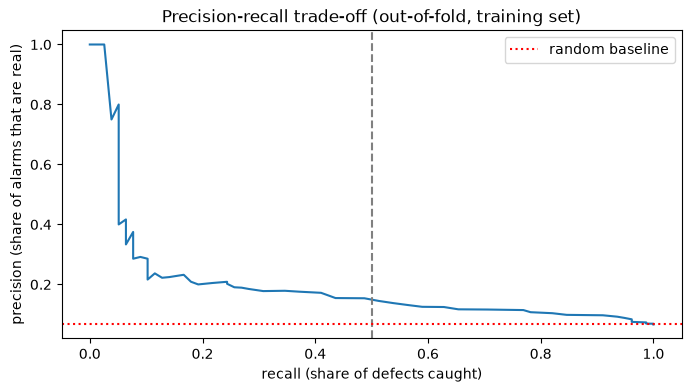

In [27]:
best_rf = search.best_estimator_
oof_proba = cross_val_predict(best_rf, X_train, y_train, cv=cv, method="predict_proba")[:, 1]

precision, recall, thresholds = precision_recall_curve(y_train, oof_proba)
TARGET_RECALL = 0.5
# highest threshold that still gives the target recall
ok = np.where(recall[:-1] >= TARGET_RECALL)[0]
threshold = thresholds[ok[-1]]
print(f"Chosen threshold: {threshold:.3f} (train OOF precision {precision[ok[-1]]:.2f}, recall {recall[ok[-1]]:.2f})")

plt.plot(recall, precision)
plt.axvline(TARGET_RECALL, ls="--", c="grey")
plt.axhline(y_train.mean(), ls=":", c="red", label="random baseline")
plt.xlabel("recall (share of defects caught)"); plt.ylabel("precision (share of alarms that are real)")
plt.title("Precision-recall trade-off (out-of-fold, training set)"); plt.legend(); plt.show()

### Final evaluation on the held-out test set

Test ROC AUC:           0.778
Test average precision: 0.234  (random = 0.066)


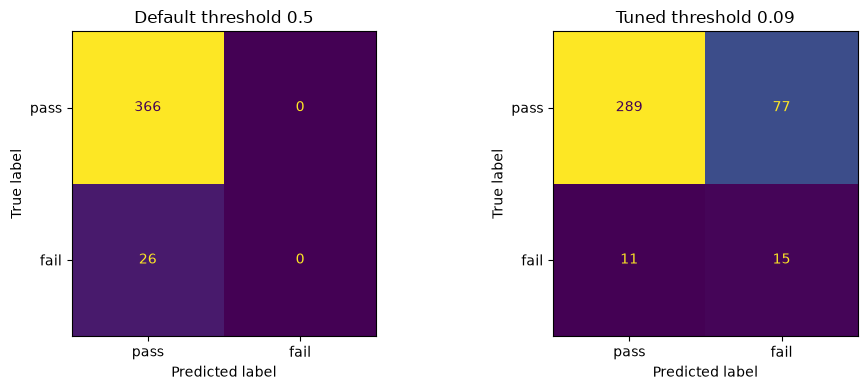

              precision    recall  f1-score   support

        pass      0.963     0.790     0.868       366
        fail      0.163     0.577     0.254        26

    accuracy                          0.776       392
   macro avg      0.563     0.683     0.561       392
weighted avg      0.910     0.776     0.827       392



In [28]:
best_rf.fit(X_train, y_train)
test_proba = best_rf.predict_proba(X_test)[:, 1]

print(f"Test ROC AUC:           {roc_auc_score(y_test, test_proba):.3f}")
print(f"Test average precision: {average_precision_score(y_test, test_proba):.3f}  (random = {y_test.mean():.3f})")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, thr, title in [(axes[0], 0.5, "Default threshold 0.5"), (axes[1], threshold, f"Tuned threshold {threshold:.2f}")]:
    pred = (test_proba >= thr).astype(int)
    ConfusionMatrixDisplay(confusion_matrix(y_test, pred), display_labels=["pass", "fail"]).plot(ax=ax, colorbar=False)
    ax.set_title(title)
plt.tight_layout(); plt.show()

print(classification_report(y_test, (test_proba >= threshold).astype(int), target_names=["pass", "fail"], digits=3))

With the default threshold the model catches almost nothing. After choosing the threshold on training data, it catches a meaningful share of defects on parts it has never seen, at the cost of false alarms. Whether this trade-off is acceptable depends on the cost of an inspection versus the cost of a missed defect, which is a conversation with the process engineers, not a purely technical choice.

## 7. Time-based validation: is the random split too optimistic?

In production a model is trained on past data and used on future data. The data is sorted by time, so I train on the first 75% of parts and test on the last 25%.

In [29]:
cut = int(len(X) * 0.75)
X_past, X_future = X.iloc[:cut], X.iloc[cut:]
y_past, y_future = y.iloc[:cut], y.iloc[cut:]
print(f"Train period ends: {labels['timestamp'].iloc[cut-1]:%Y-%m-%d}; test: {len(X_future)} parts, {y_future.sum()} defects")

rows = []
for name in ["Logistic regression", "Random forest"]:
    model = best_rf if name == "Random forest" else make_pipeline(models[name])
    for split, (Xa, ya, Xb, yb) in {"random split": (X_train, y_train, X_test, y_test),
                                    "time split": (X_past, y_past, X_future, y_future)}.items():
        p = model.fit(Xa, ya).predict_proba(Xb)[:, 1]
        rows.append({"model": name, "split": split, "ROC AUC": roc_auc_score(yb, p),
                     "Avg precision": average_precision_score(yb, p)})
pd.DataFrame(rows).pivot(index="model", columns="split").round(3)

Train period ends: 2008-09-29; test: 392 parts, 24 defects


ROC AUC            Avg precision           
split               random split time split  random split time split
model                                                               
Logistic regression        0.674      0.672         0.128      0.100
Random forest              0.778      0.559         0.234      0.087

**The random forest that looked best on the random split drops to roughly random performance on future data.** Logistic regression, which is simpler, is much more stable.

My interpretation: the process changed over time (we saw the defect rate fall from ~22% to ~3%), and the flexible random forest learned patterns specific to the earlier period. The random split hid this because training and test parts came from the same weeks.

Practical lessons:
- validate models on a time-based split when the data has a time order
- a more complex model is not automatically better in production
- a deployed model needs monitoring for drift and a retraining plan

## 8. Anomaly detection without labels: IsolationForest

In practice, labelled defects are often rare or arrive late. Can we flag suspicious parts using sensor data alone? I train `IsolationForest` only on **good parts** from the training set, so it learns what "normal" looks like, then score the test parts. Labels are used only to check the result.

In [30]:
iso = Pipeline(make_pipeline(None).steps[:-1] +
               [("model", IsolationForest(n_estimators=300, random_state=RANDOM_STATE))])
iso.fit(X_train[y_train == 0])

anomaly_score = -iso.score_samples(X_test)   # higher = more unusual
print(f"ROC AUC of anomaly score vs real defects: {roc_auc_score(y_test, anomaly_score):.3f}")

for top in [0.05, 0.10, 0.20]:
    k = int(len(X_test) * top)
    flagged = np.argsort(anomaly_score)[::-1][:k]
    caught = y_test.iloc[flagged].sum()
    print(f"Flag the {top:.0%} most unusual parts ({k}): {caught} of {y_test.sum()} defects caught "
          f"(random would catch ~{y_test.sum()*top:.1f})")

ROC AUC of anomaly score vs real defects: 0.593
Flag the 5% most unusual parts (19): 4 of 26 defects caught (random would catch ~1.3)
Flag the 10% most unusual parts (39): 5 of 26 defects caught (random would catch ~2.6)
Flag the 20% most unusual parts (78): 9 of 26 defects caught (random would catch ~5.2)


Without seeing a single defect, IsolationForest does better than random but clearly worse than the supervised model. It is useful as an extra signal or when there are no labels yet, not as a replacement for a supervised model.

## 9. Which sensors matter most?

I use **permutation importance** on the test set: shuffle one sensor at a time and measure how much average precision drops. Unlike the built-in random forest importance, it is measured on unseen data and is not biased towards features with many distinct values.

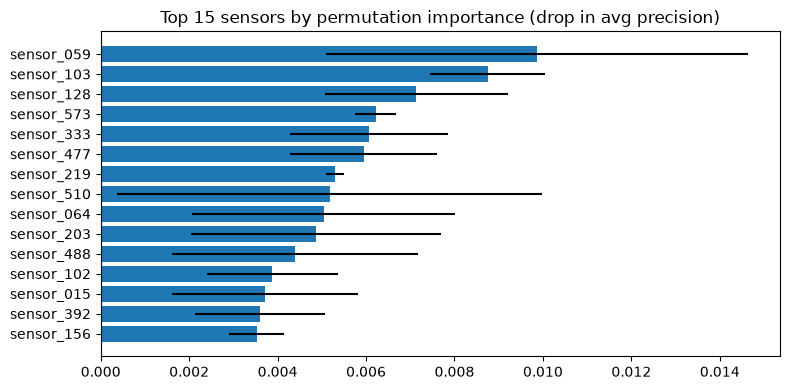

,importance,std
sensor_059,0.0099,0.0048
sensor_103,0.0087,0.0013
sensor_128,0.0071,0.0021
sensor_573,0.0062,0.0005
sensor_333,0.0061,0.0018
sensor_477,0.0059,0.0017
sensor_219,0.0053,0.0002
sensor_510,0.0052,0.0048
sensor_064,0.0050,0.0030
sensor_203,0.0049,0.0028


In [31]:
perm = permutation_importance(best_rf, X_test, y_test, scoring="average_precision",
                              n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1)
imp = (pd.DataFrame({"importance": perm.importances_mean, "std": perm.importances_std}, index=X_test.columns)
       .sort_values("importance", ascending=False))

top = imp.head(15)[::-1]
plt.barh(top.index, top["importance"], xerr=top["std"])
plt.title("Top 15 sensors by permutation importance (drop in avg precision)")
plt.tight_layout(); plt.show()
imp.head(10).round(4)

The sensors are anonymised, so I cannot say what they physically measure. In a real plant this list would be the starting point for a conversation with process engineers: are these signals plausibly linked to the failure modes? Given the large error bars and only ~26 defects in the test set, I would treat this as a shortlist to investigate, not a final answer.

## 10. Summary and limitations

**What worked**
- A leakage-safe `Pipeline` handled missing values and ~116 constant sensors
- Class weighting plus a threshold chosen on out-of-fold predictions turned a model that caught almost no defects into one that catches a meaningful share of them
- Average precision and recall were far more informative than accuracy

**What I learned from the data**
- The signal is weak: process sensors alone predict failures only partly
- The process drifts over time, and the best model on a random split was the worst on future data. Time-based validation changed which model I would choose

**Limitations and next steps**
- Few defects (104 in total), so all metrics have high variance
- Sensors are anonymised, so no domain knowledge could be used for feature engineering
- Next steps: feature selection, rolling-window retraining to handle drift, monitoring prediction quality over time, and working with domain experts on the most important sensors